<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D0%B9_%D0%BF%D0%BB%D0%B0%D1%82%D1%84%D0%BE%D1%80%D0%BC%D1%8B/%D0%9D%D0%B5%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D0%BA%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B8_%D0%B7%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D1%8B%D1%85_%D0%B2%D1%8B%D0%B1%D0%BE%D1%80%D0%BE%D0%BA/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BE%D0%BF%D1%80%D0%BE%D1%81%D0%B0_%D0%BF%D0%BE_%D0%B8%D0%B7%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D1%8E_%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D0%B9_%D0%BF%D0%BB%D0%B0%D1%82%D1%84%D0%BE%D1%80%D0%BC%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Одновыборочный критерий Колмогорова-Смирнова до изменения:KstestResult(statistic=np.float64(0.178211426537558), pvalue=np.float64(0.26362560145372904), statistic_location=np.int64(6), statistic_sign=np.int8(-1))
Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:KstestResult(statistic=np.float64(0.128282105869995), pvalue=np.float64(0.6599729305201979), statistic_location=np.int64(8), statistic_sign=np.int8(-1))
Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:KstestResult(statistic=np.float64(0.24710662443492598), pvalue=np.float64(0.042376912314184834), statistic_location=np.int64(8), statistic_sign=np.int8(-1))
Непараметрический критерий Фридмана для 3-х выборок: FriedmanchisquareResult(statistic=np.float64(5.504587155963303), pvalue=np.float64(0.0637814056896069))
Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: WilcoxonResult(statistic=np.float64(128.5), pvalue=np.float64(0.7713234078404343))
Непараметрический критерий Вилкоксона для 2-х выбор

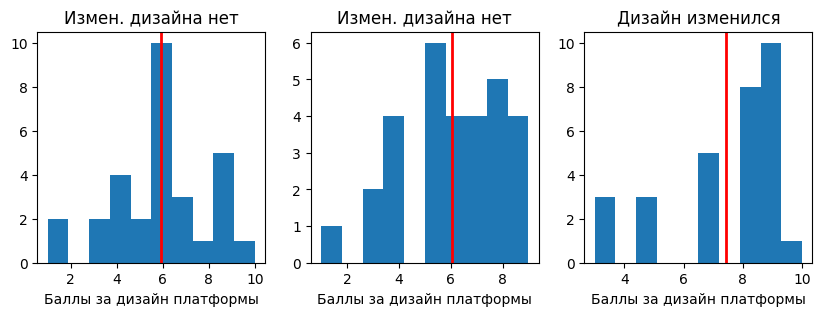

In [ ]:
from numpy.ma import setdiff1d
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import ks_1samp, wilcoxon, friedmanchisquare, norm
df1=pd.read_csv("befor.csv")
df2=pd.read_csv("after_first_update.csv")
df3=pd.read_csv("after_second_update.csv")
df1=df1['Q3']
df2=df2['Q3']
df3=df3['Q3']
#df1 = df1.dropna().reset_index(drop=True)
#df2 = df2.dropna().reset_index(drop=True)
#df3 = df3.dropna().reset_index(drop=True)
# Визуализация
fig,ax=plt.subplots(1,3,figsize=(10,3))
ax[0].hist(df1)
ax[1].hist(df2)
ax[2].hist(df3)
ax[0].set_title('Измен. дизайна нет')
ax[1].set_title('Измен. дизайна нет')
ax[2].set_title('Дизайн изменился')
ax[0].set_xlabel('Баллы за дизайн платформы')
ax[1].set_xlabel('Баллы за дизайн платформы')
ax[2].set_xlabel('Баллы за дизайн платформы')
# Для количественной шкалы используем среднее
mean1 = df1.mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = df2.mean()
ax[1].axvline(mean2, color='red', linewidth=2)
mean3 = df3.mean()
ax[2].axvline(mean3, color='red', linewidth=2)
# Проверка на нормальность - одновыборочный критерий Колмогорова-Смирнова
std1=df1.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова до изменения:{ks_1samp(df1, norm.cdf, args=(mean1, std1))}")
# p=0.263 > a=0.05 - гипотезу о нормальности выборки не отвергаем
std2=df2.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:{ks_1samp(df2, norm.cdf, args=(mean2, std2))}")
# p=0.66 > a=0.05 - гипотезу о нормальности выборки не отвергаем
std3=df3.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:{ks_1samp(df3, norm.cdf, args=(mean3, std3))}")
# p=0.042 < a=0.05 - гипотезу о нормальности выборки отвергаем
# Не все выборки имеют нормальное распределение. Используем непараметрические методы - для трех и более выборок Критерий Фридмана
print(f"Непараметрический критерий Фридмана для 3-х выборок: {friedmanchisquare(df1, df2, df3)}")
# p_value=0.064 > a=0.05 - гипотезу о том, что выборки взяты из одного распределения и новый дизайн не оказал влияние на пользователей не отвергаем
# Судя по гистограмме среднее увеличилось после измененния дизайна - используем критерий Вилкоксона дл 2-х выборок (2 и 3)
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: {wilcoxon(df1,df2)}")
# При попарном сравнении нужно делать поправки на уровень значимости, так как совершить ошибку в трех тестах много выше, чем в одном.
# Поэтому вспомним табличку с рекомендациями по выбору уровня значимости при множественных сравнениях
# У нас сравнивается 3 выборки, значит следует выбрать уровень значимости 0.017
# p_value=0.771 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и новый дизайн не оказал влияние на пользователей не отвергаем
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 2 и 3: {wilcoxon(df2,df3)}")
# p_value=0.026 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и новый дизайн не оказал влияние на пользователей не отвергаем
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 1 и 3: {wilcoxon(df1,df3)}")
# p_value=0.0067 < a=0.017 - гипотезу о том, что выборки взяты из одного распределения и новый дизайн не оказал влияние на пользователей отвергаем
print(f"Средние 1-й и 3-й выборки: {mean1:.2f},{mean3:.2f}")
print(f"Cтандартное отклонение 1-й и 3-й выборки: {std1:.2f},{std3:.2f}")
# Несмотря на то, что критерий Фридмана не выявил статистически значимые различия между тремя опросами (p=0.063),
# попарное сравнение с поправкой подтвердило значимые изменения между 1 и 3 опросом (p>0.067).
# Это может указывать на разнонаправленные индивидуальные изменения оценок, которые не привели к систематическому сдвигу.
# Рекомендация: провести тест повторно для большей выборки.

Одновыборочный критерий Колмогорова-Смирнова до изменения:KstestResult(statistic=np.float64(0.260907078748682), pvalue=np.float64(0.027298994729231696), statistic_location=np.int64(2), statistic_sign=np.int8(1))
Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:KstestResult(statistic=np.float64(0.2193170407977847), pvalue=np.float64(0.09532189286624626), statistic_location=np.int64(3), statistic_sign=np.int8(1))
Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:KstestResult(statistic=np.float64(0.19265375076560776), pvalue=np.float64(0.18903990919078573), statistic_location=np.int64(3), statistic_sign=np.int8(1))
Непараметрический критерий Фридмана для 3-х выборок: FriedmanchisquareResult(statistic=np.float64(7.032258064516114), pvalue=np.float64(0.02971423567779066))
Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: WilcoxonResult(statistic=np.float64(76.5), pvalue=np.float64(0.16580656019401352))
Непараметрический критерий Вилкоксона для 2-х выбор

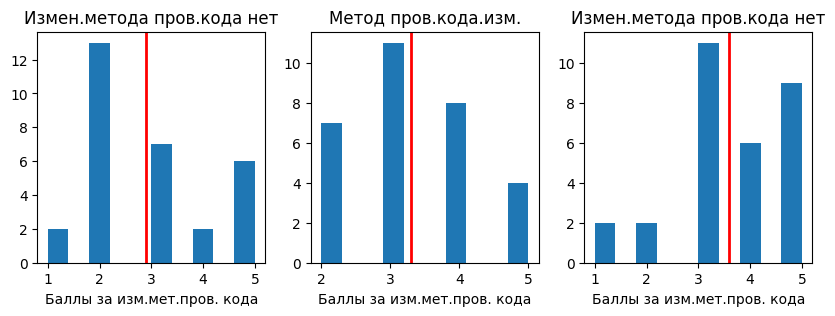

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import ks_1samp, wilcoxon, friedmanchisquare, norm
df1=pd.read_csv("befor.csv")
df2=pd.read_csv("after_first_update.csv")
df3=pd.read_csv("after_second_update.csv")
df1=df1['Q1']
df2=df2['Q1']
df3=df3['Q1']
df1 = df1.dropna().reset_index(drop=True)
df2 = df2.dropna().reset_index(drop=True)
df3 = df3.dropna().reset_index(drop=True)
mapping = {
    'Очень удовлетворен(а)': 5,
    'Удовлетворен(а)': 4,
    'Нейтрален(на)': 3,
    'Недоволен(а)': 2,
    'Очень недоволен(а)': 1
}
df1 = df1.map(mapping)
df2 = df2.map(mapping)
df3 = df3.map(mapping)
# Визуализация
fig,ax=plt.subplots(1,3,figsize=(10,3))
ax[0].hist(df1)
ax[1].hist(df2)
ax[2].hist(df3)
ax[0].set_title('Измен.метода пров.кода нет')
ax[1].set_title('Метод пров.кода.изм.')
ax[2].set_title('Измен.метода пров.кода нет')
ax[0].set_xlabel('Баллы за изм.мет.пров. кода')
ax[1].set_xlabel('Баллы за изм.мет.пров. кода')
ax[2].set_xlabel('Баллы за изм.мет.пров. кода')
# Для порядковых переменных используем медиану
median1 = df1.mean()
median2 = df2.mean()
median3 = df3.mean()
ax[0].axvline(median1, color='red', linewidth=2)
ax[1].axvline(median2, color='red', linewidth=2)
ax[2].axvline(median3, color='red', linewidth=2)
# Проверка на нормальность - одновыборочный критерий Колмогорова-Смирнова
mean=df1.mean()
std=df1.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова до изменения:{ks_1samp(df1, norm.cdf, args=(mean, std))}")
# p=0.027 < a=0.05 - гипотезу о нормальности выборки отвергаем
mean=df2.mean()
std=df2.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:{ks_1samp(df2, norm.cdf, args=(mean, std))}")
# p=0.095 > a=0.05 - гипотезу о нормальности выборки не отвергаем
mean=df3.mean()
std=df3.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:{ks_1samp(df3, norm.cdf, args=(mean, std))}")
# p=0.189 > a=0.05 - гипотезу о нормальности выборки не отвергаем
# Не все выборки имеют нормальное распределение. Используем непараметрические методы - для трех и более выборок Критерий Фридмана
print(f"Непараметрический критерий Фридмана для 3-х выборок: {friedmanchisquare(df1, df2, df3)}")
# p_value=0.029 < a=0.05 - отвергаем гипотезу о том, что выборки взяты из одного распределения и новый метод проверки кода не оказал влияние на пользователей
# Судя по гистограмме медиана увеличилась после измененния дизайна - используем критерий Вилкоксона дл 2-х выборок (2 и 3)
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: {wilcoxon(df1,df2)}")
# При попарном сравнении нужно делать поправки на уровень значимости, так как совершить ошибку в трех тестах много выше, чем в одном.
# оэтому вспомним табличку с рекомендациями по выбору уровня значимости при множественных сравнениях
# У нас сравнивается 3 выборки, значит следует выбрать уровень значимости 0.017
# p_value=0.165 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение кода не оказал влияние на пользователей не отвергаем
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 2 и 3: {wilcoxon(df2,df3)}")
# p_value=0.28 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение кода не оказал влияние на пользователей не отвергаем
print(f"Непараметрический критерий Вилкоксона для 1-х выборок 2 и 3: {wilcoxon(df1,df3)}")
# p_value=0.058 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение кода не оказал влияние на пользователей не отвергаем
# Несмотря на то, что критерий Фридмана выявил статистически значимые различия между тремя опросами (p=0.029),
# попарное сравнение с поправкой не подтвердило значимых изменений ни между одной парой опросов (p>0.017).
# Это может указывать на разнонаправленные индивидуальные изменения оценок, которые не привели к систематическому сдвигу.
# Рекомендация: провести тест повторно для большей выборки.

Одновыборочный критерий Колмогорова-Смирнова до изменения:KstestResult(statistic=np.float64(0.31083157943982886), pvalue=np.float64(0.004505211898643058), statistic_location=np.int64(2), statistic_sign=np.int8(1))
Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:KstestResult(statistic=np.float64(0.20777712988478947), pvalue=np.float64(0.12964073918347063), statistic_location=np.int64(3), statistic_sign=np.int8(1))
Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:KstestResult(statistic=np.float64(0.2746453975277058), pvalue=np.float64(0.01718876275842507), statistic_location=np.int64(3), statistic_sign=np.int8(1))
Непараметрический критерий Фридмана для 3-х выборок: FriedmanchisquareResult(statistic=np.float64(15.859999999999967), pvalue=np.float64(0.0003597864129304889))
Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: WilcoxonResult(statistic=np.float64(42.0), pvalue=np.float64(0.0015515950877547252))
Непараметрический критерий Вилкоксона для 2-

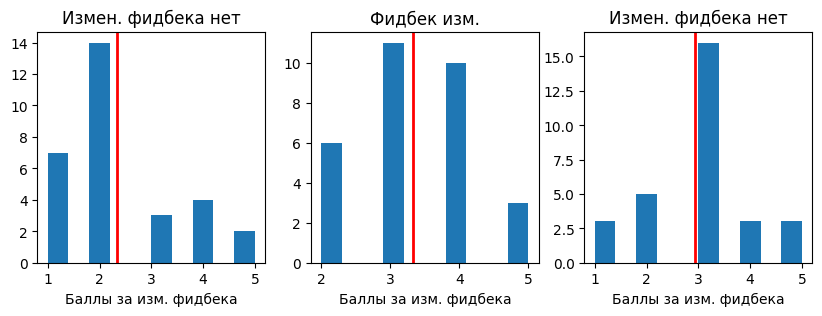

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import ks_1samp, wilcoxon, friedmanchisquare, norm
df1=pd.read_csv("befor.csv")
df2=pd.read_csv("after_first_update.csv")
df3=pd.read_csv("after_second_update.csv")
df1=df1['Q2']
df2=df2['Q2']
df3=df3['Q2']
df1 = df1.dropna().reset_index(drop=True)
df2 = df2.dropna().reset_index(drop=True)
df3 = df3.dropna().reset_index(drop=True)
mapping = {
    'Очень быстро': 5,
    'Довольно быстро': 4,
    'Средне': 3,
    'Медленно': 2,
    'Очень медленно': 1
}
df1 = df1.map(mapping)
df2 = df2.map(mapping)
df3 = df3.map(mapping)
# Визуализация
fig,ax=plt.subplots(1,3,figsize=(10,3))
ax[0].hist(df1)
ax[1].hist(df2)
ax[2].hist(df3)
ax[0].set_title('Измен. фидбека нет')
ax[1].set_title('Фидбек изм.')
ax[2].set_title('Измен. фидбека нет')
ax[0].set_xlabel('Баллы за изм. фидбека')
ax[1].set_xlabel('Баллы за изм. фидбека')
ax[2].set_xlabel('Баллы за изм. фидбека')
# Для порядковых переменных используем медиану
median1 = df1.mean()
median2 = df2.mean()
median3 = df3.mean()
ax[0].axvline(median1, color='red', linewidth=2)
ax[1].axvline(median2, color='red', linewidth=2)
ax[2].axvline(median3, color='red', linewidth=2)
# Проверка на нормальность - одновыборочный критерий Колмогорова-Смирнова
mean=df1.mean()
std=df1.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова до изменения:{ks_1samp(df1, norm.cdf, args=(mean, std))}")
# p=0.004 < a=0.05 - гипотезу о нормальности выборки отвергаем
mean=df2.mean()
std=df2.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова после 1-го изменения:{ks_1samp(df2, norm.cdf, args=(mean, std))}")
# p=0.129 > a=0.05 - гипотезу о нормальности выборки не отвергаем
mean=df3.mean()
std=df3.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова 2-го изменения:{ks_1samp(df3, norm.cdf, args=(mean, std))}")
# p=0.0171 < a=0.05 - гипотезу о нормальности выборки отвергаем
# Не все выборки имеют нормальное распределение. Используем непараметрические методы - для трех и более выборок Критерий Фридмана
print(f"Непараметрический критерий Фридмана для 3-х выборок: {friedmanchisquare(df1, df2, df3)}")
# p_value=0.00036 < a=0.05 - отвергаем гипотезу о том, что выборки взяты из одного распределения и фидбек не оказал влияние на пользователей
# Судя по гистограмме медиана увеличилась после измененния дизайна - используем критерий Вилкоксона дл 2-х выборок (1 и 2)
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 1 и 2: {wilcoxon(df1,df2)}")
# При попарном сравнении нужно делать поправки на уровень значимости, так как совершить ошибку в трех тестах много выше, чем в одном.
# оэтому вспомним табличку с рекомендациями по выбору уровня значимости при множественных сравнениях
# У нас сравнивается 3 выборки, значит следует выбрать уровень значимости 0.017
# p_value=0.0015 < a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение кода не оказал влияние на пользователей отвергаем
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 2 и 3: {wilcoxon(df2,df3)}")
# p_value=0.09 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение фидбека не оказал влияние на пользователей не отвергаем
print(f"Непараметрический критерий Вилкоксона для 2-х выборок 1 и 3: {wilcoxon(df1,df3)}")
# p_value=0.043 > a=0.017 - гипотезу о том, что выборки взяты из одного распределения и изменение фидбека не оказал влияние на пользователей не отвергаем
print(f"Медиана 1-й и 2-й выборки: {median1:.2f},{median2:.2f}")
print(f"Cтандартное отклонение 1-й и 2-й выборки: {std1:.2f},{std2:.2f}")
# Медианы 1 и 2 выборки изменились в сторону увеличения, значит изменение произошло в сторону улучшения